In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style

In [4]:
# Sampling rate and time vector
srate = 256  # Hz
t = np.arange(0, 3, 1 / srate)
pnts = len(t)
pnts
t

array([0.        , 0.00390625, 0.0078125 , 0.01171875, 0.015625  ,
       0.01953125, 0.0234375 , 0.02734375, 0.03125   , 0.03515625,
       0.0390625 , 0.04296875, 0.046875  , 0.05078125, 0.0546875 ,
       0.05859375, 0.0625    , 0.06640625, 0.0703125 , 0.07421875,
       0.078125  , 0.08203125, 0.0859375 , 0.08984375, 0.09375   ,
       0.09765625, 0.1015625 , 0.10546875, 0.109375  , 0.11328125,
       0.1171875 , 0.12109375, 0.125     , 0.12890625, 0.1328125 ,
       0.13671875, 0.140625  , 0.14453125, 0.1484375 , 0.15234375,
       0.15625   , 0.16015625, 0.1640625 , 0.16796875, 0.171875  ,
       0.17578125, 0.1796875 , 0.18359375, 0.1875    , 0.19140625,
       0.1953125 , 0.19921875, 0.203125  , 0.20703125, 0.2109375 ,
       0.21484375, 0.21875   , 0.22265625, 0.2265625 , 0.23046875,
       0.234375  , 0.23828125, 0.2421875 , 0.24609375, 0.25      ,
       0.25390625, 0.2578125 , 0.26171875, 0.265625  , 0.26953125,
       0.2734375 , 0.27734375, 0.28125   , 0.28515625, 0.28906

In [12]:
# Creating a noiseless signal
x_clean = np.sin(2 * np.pi * 2 * t)

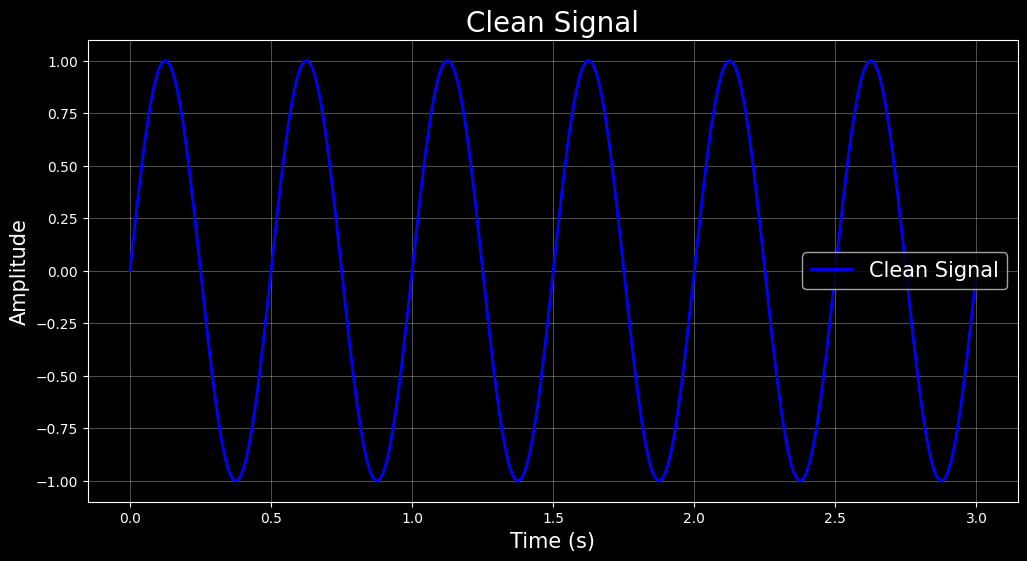

In [13]:
# Plot the clean signal
plt.figure(figsize=(12, 6))
style.use('dark_background')
plt.plot(t, x_clean, label="Clean Signal", linewidth=2, color='blue')
plt.title("Clean Signal", fontsize=20)
plt.xlabel("Time (s)", fontsize=15)
plt.ylabel("Amplitude", fontsize=15)
plt.grid(alpha=0.3)
plt.legend(fontsize=15)
plt.show()

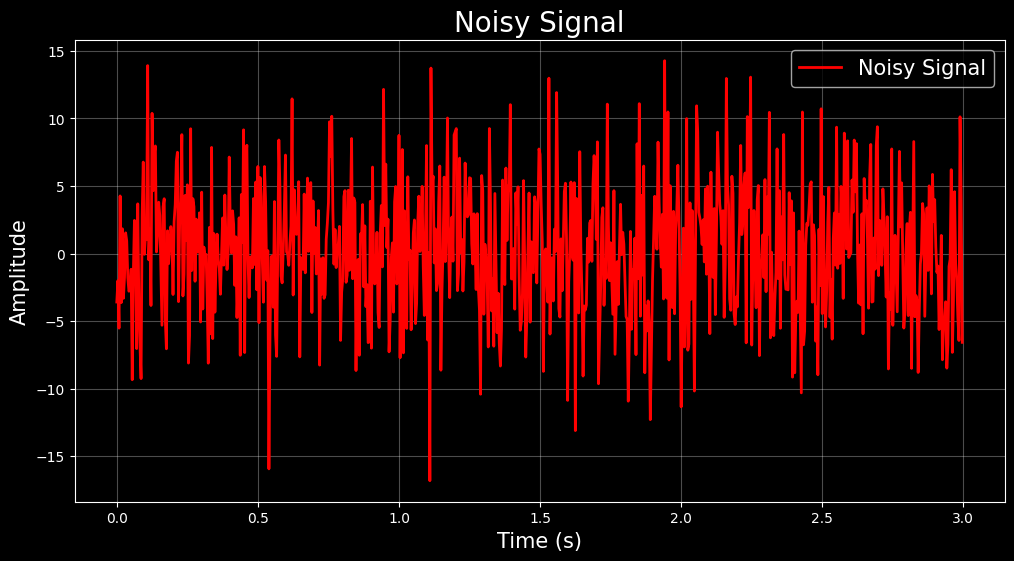

In [14]:

# Creating random noise
noise = 5 * np.random.randn(pnts)

# Adding noise to the signal
Noisysignal = x_clean + noise
x = Noisysignal

# Plot the noisy signal
plt.figure(figsize=(12, 6))
style.use('dark_background')
plt.plot(t, Noisysignal, label="Noisy Signal", linewidth=2, color='red')
plt.title("Noisy Signal", fontsize=20)
plt.xlabel("Time (s)", fontsize=15)
plt.ylabel("Amplitude", fontsize=15)
plt.grid(alpha=0.3)
plt.legend(fontsize=15)
plt.show()


In [15]:
# Creating a filter (Moving Average Filter)
filter = 2 * np.ones(50) / 10  # Filter kernel
h = filter

# Length of the output signal after convolution
n = len(x) + len(h) - 1
y = np.zeros(n)

# Wizney convolution method
for i in range(n):
    for j in range(len(x)):
        if i - j >= 0 and i - j < len(h):
            y[i] += x[j] * h[i - j]

# Truncate the filtered signal to match the original signal length
y = y[:pnts]

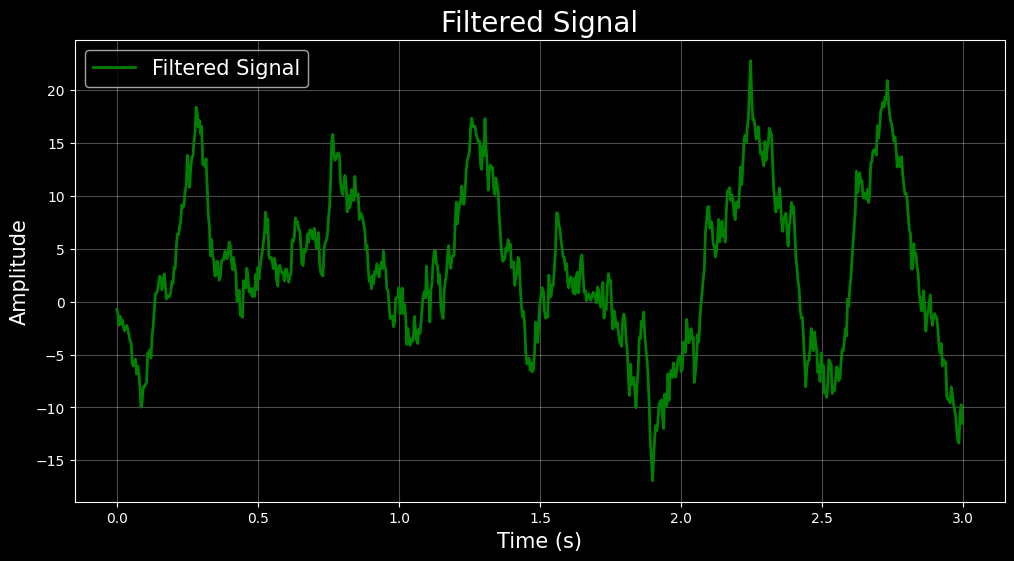

In [16]:
# Plot the filtered signal
plt.figure(figsize=(12, 6))
plt.plot(t, y, label="Filtered Signal", linewidth=2, color='green')
plt.title("Filtered Signal", fontsize=20)
plt.xlabel("Time (s)", fontsize=15)
plt.ylabel("Amplitude", fontsize=15)
plt.grid(alpha=0.3)
plt.legend(fontsize=15)
plt.show()

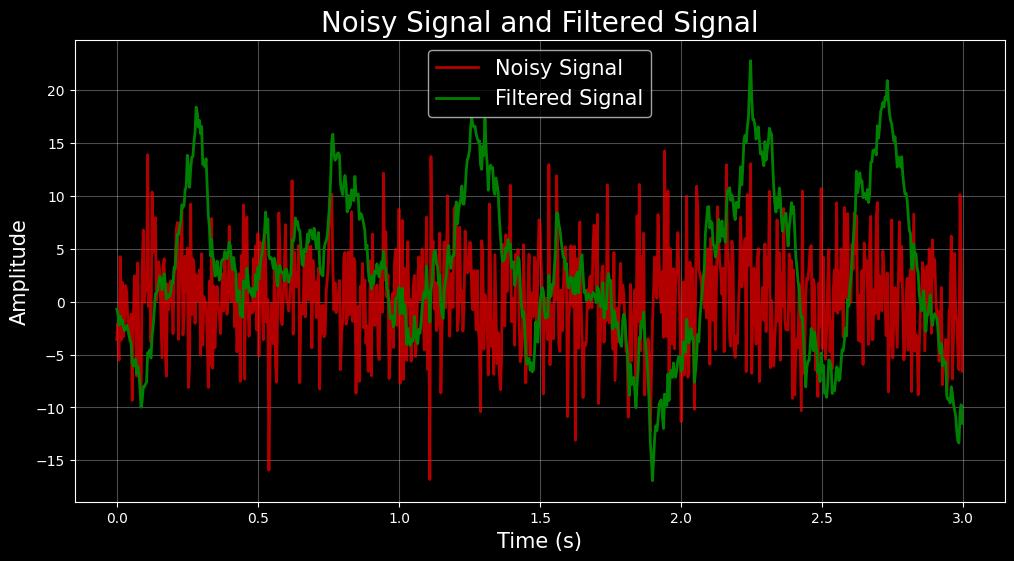

In [17]:
# Plot both noisy and filtered signals in the same graph
plt.figure(figsize=(12, 6))
plt.plot(t, Noisysignal, label="Noisy Signal", linewidth=2, color='red', alpha=0.7)
plt.plot(t, y, label="Filtered Signal", linewidth=2, color='green')
plt.title("Noisy Signal and Filtered Signal", fontsize=20)
plt.xlabel("Time (s)", fontsize=15)
plt.ylabel("Amplitude", fontsize=15)
plt.grid(alpha=0.3)
plt.legend(fontsize=15)
plt.show()

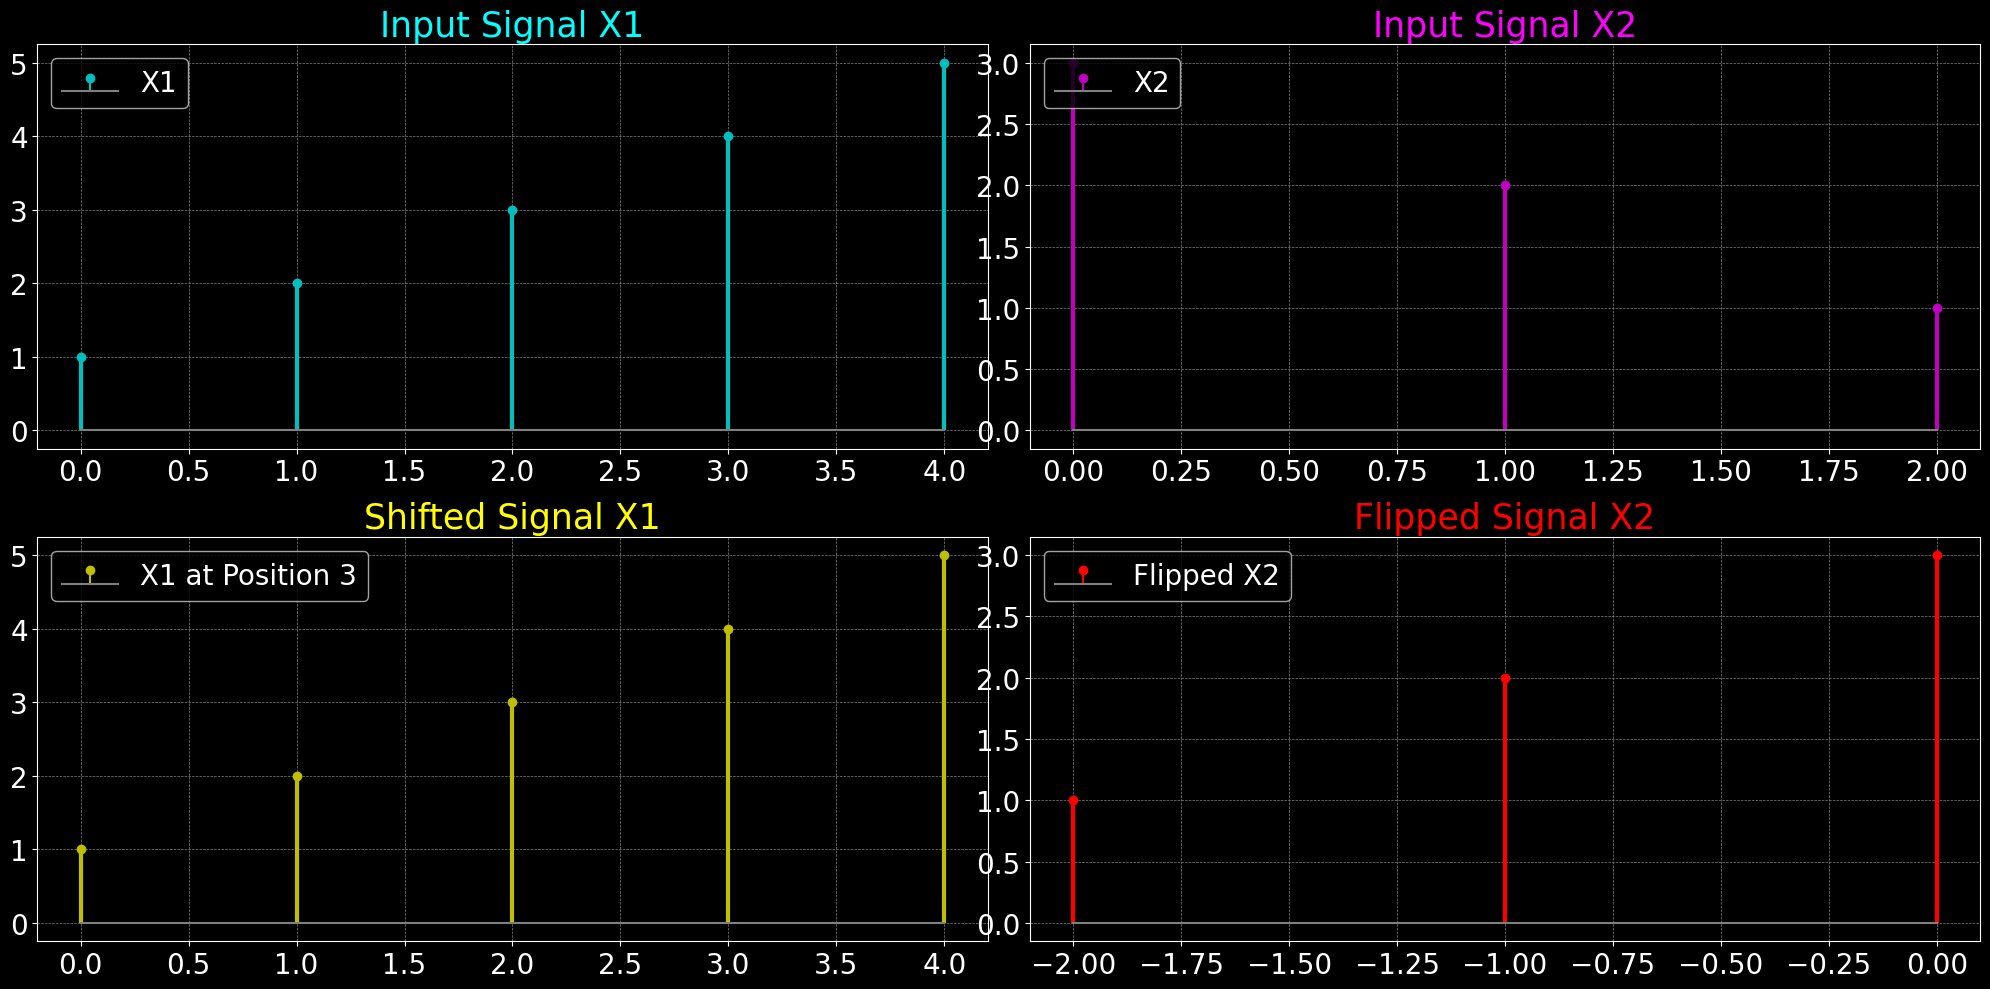

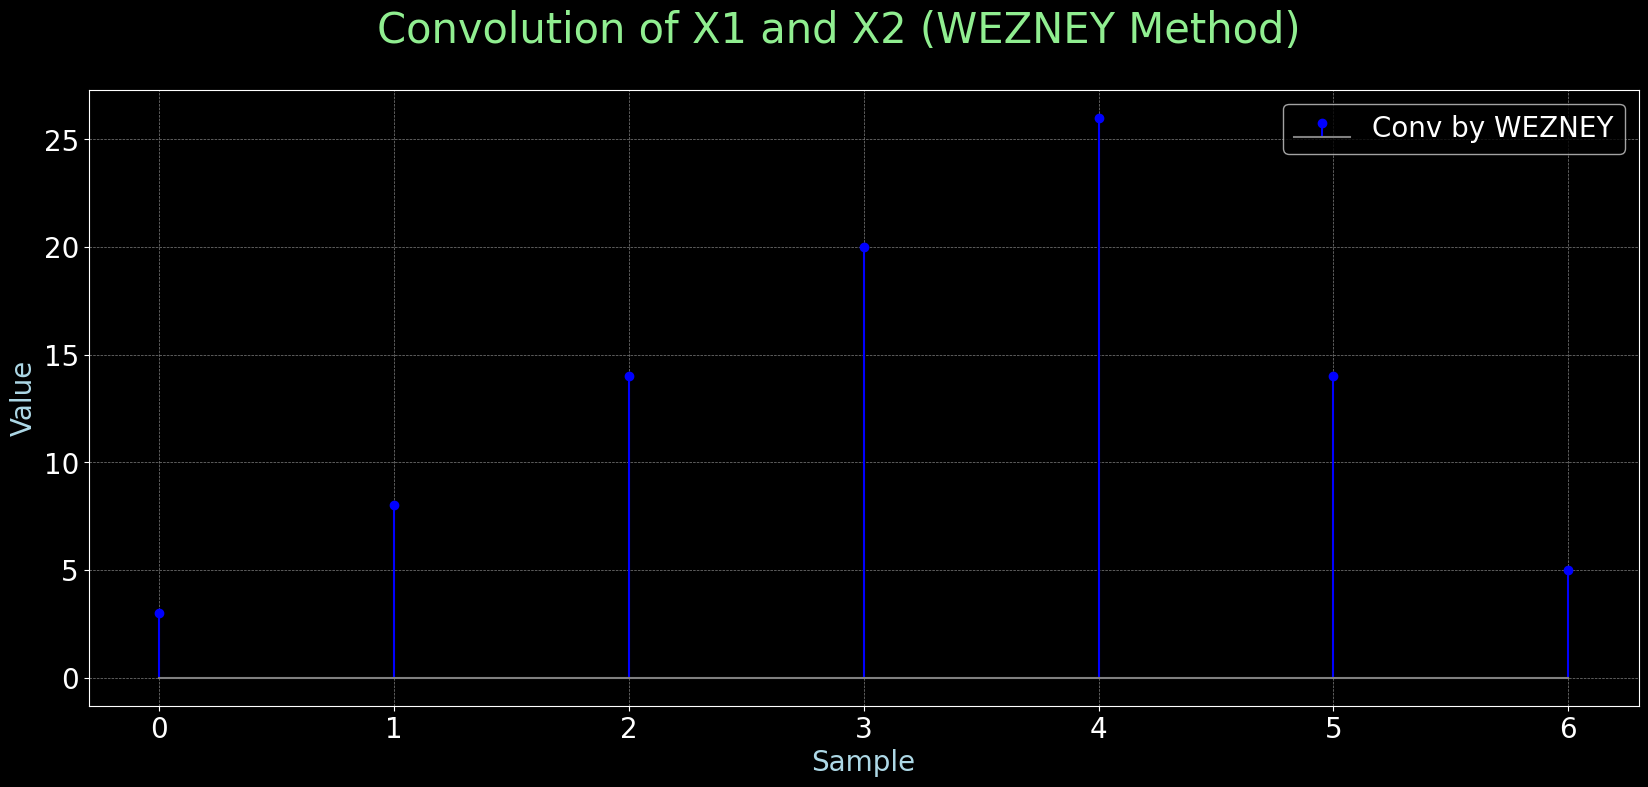

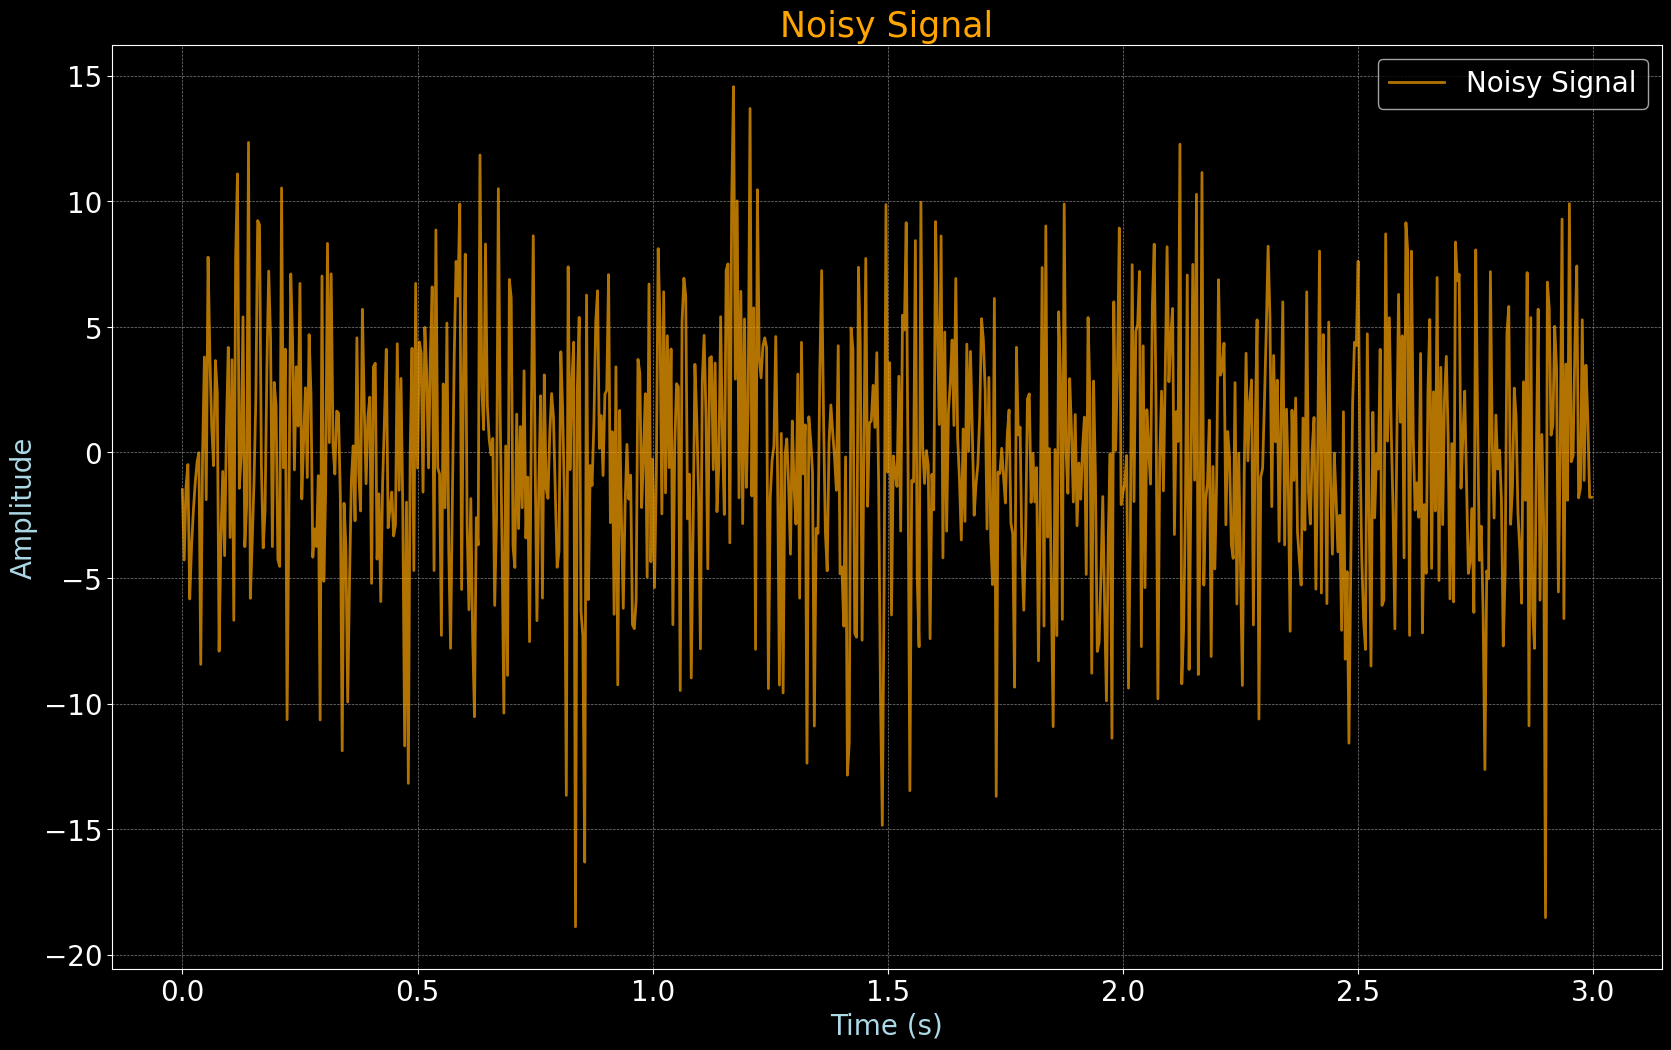

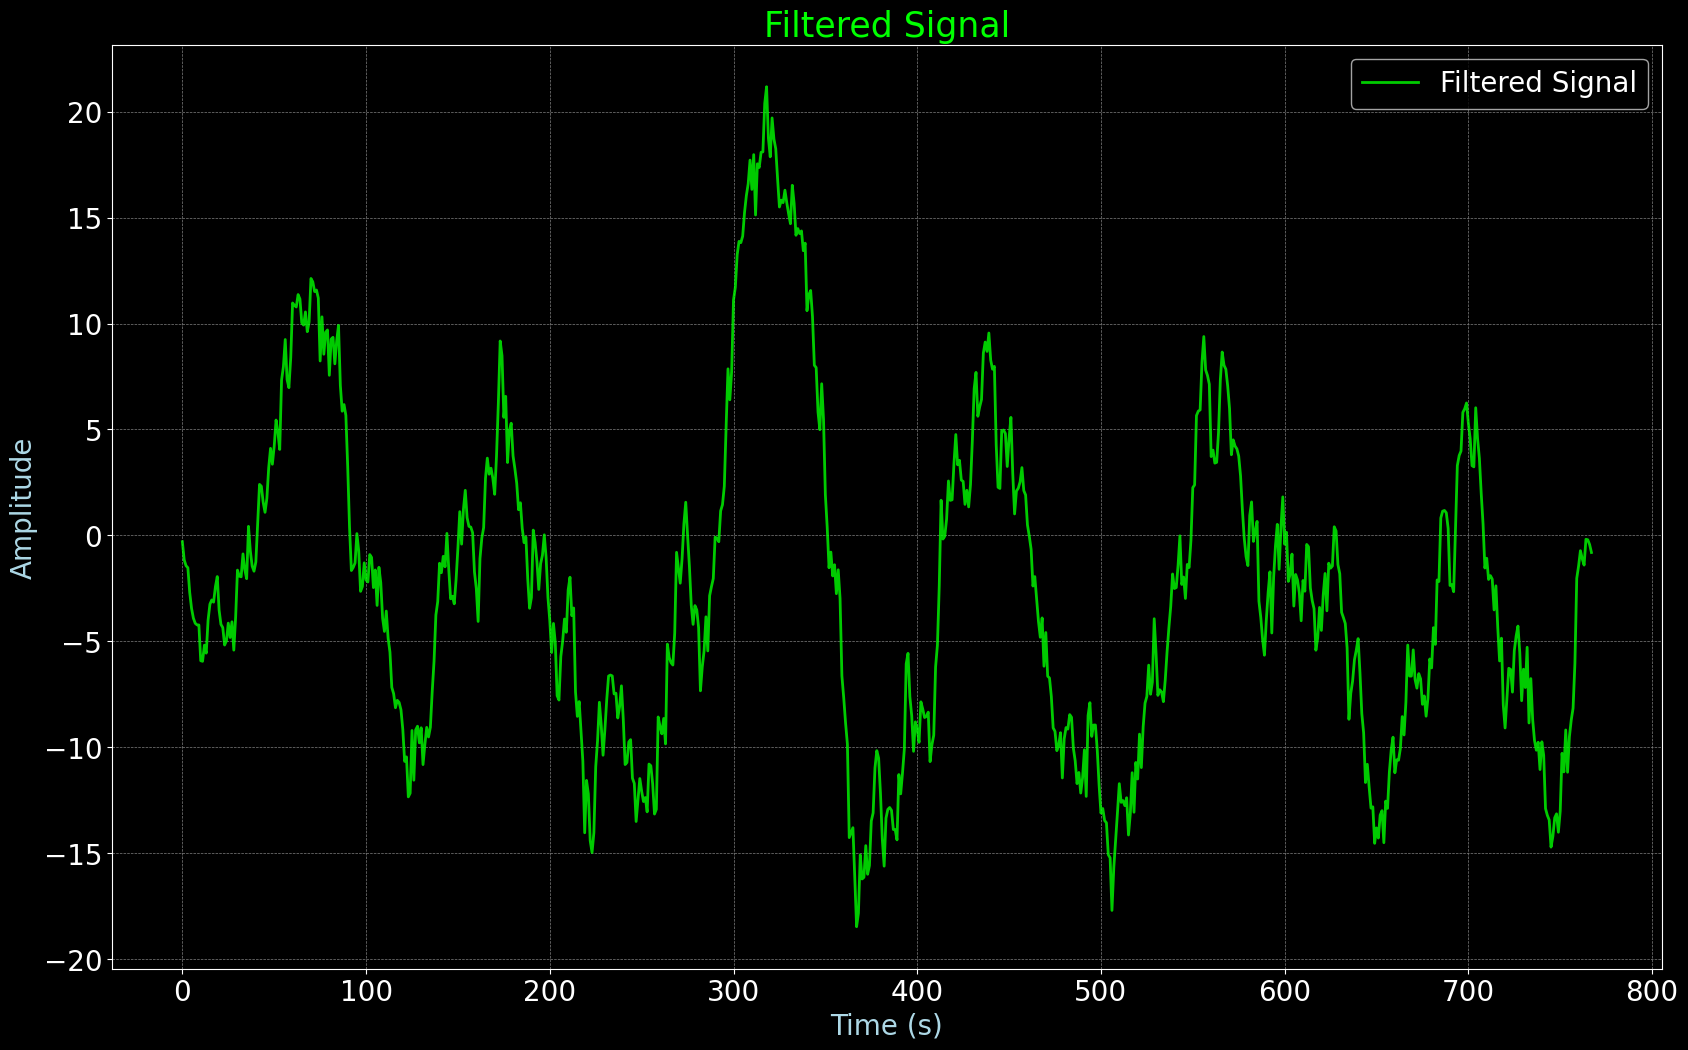

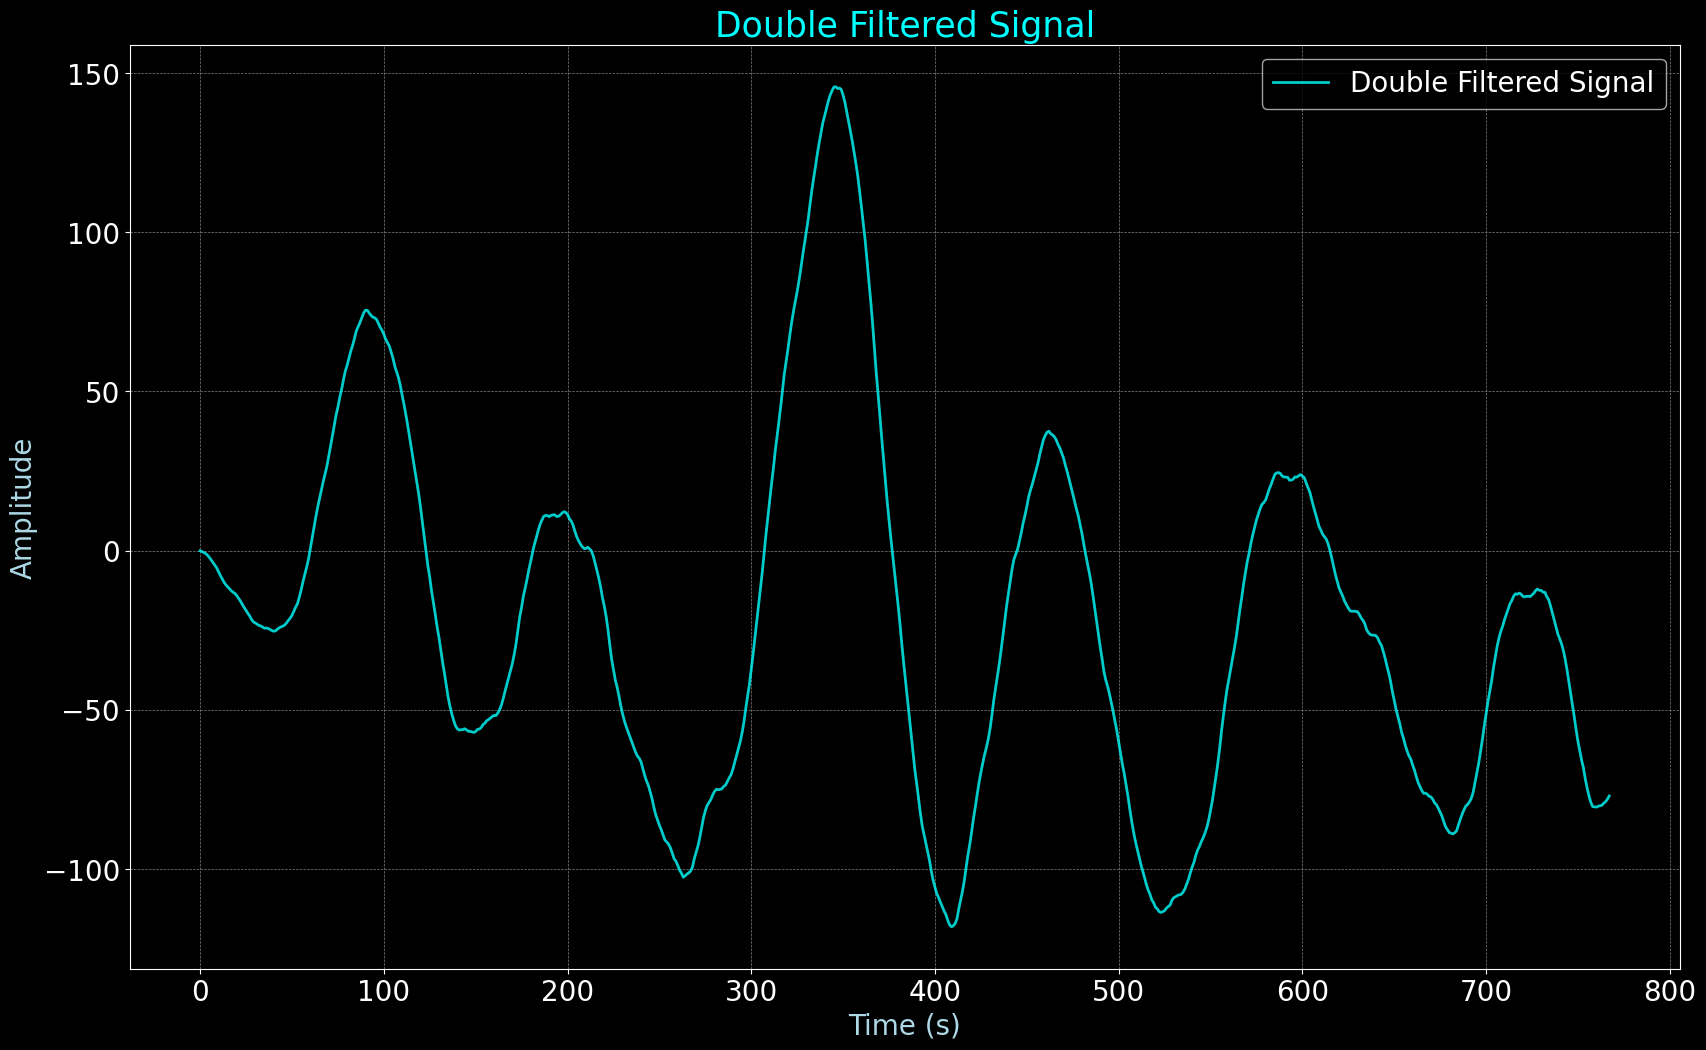

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style

# Define the manual convolution function
def wezney_convolution(x1, x2):
    len_x1 = len(x1)
    len_x2 = len(x2)
    result_len = len_x1 + len_x2 - 1
    result = np.zeros(result_len)
    for i in range(result_len):
        for j in range(len_x1):
            if 0 <= i - j < len_x2:
                result[i] += x1[j] * x2[i - j]
    return result

# Generate input signals using np.arange() and np.linspace()
n1 = np.arange(0, 5)
x1 = np.linspace(1, 5, len(n1))

n2 = np.arange(0, 3)
x2 = np.linspace(3, 1, len(n2))

# Flip x2
f_x2 = x2[::-1]
n3 = np.arange(-2, 1)

# Plotting inputs and flipped signals
plt.figure(figsize=(20, 10))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

# Plot x1
plt.subplot(2, 2, 1)
markerline, stemplines, baseline = plt.stem(n1, x1, label='X1', linefmt='c-', markerfmt='co', basefmt='gray')
plt.setp(stemplines, 'linewidth', 3)
plt.title('Input Signal X1', fontsize=25, color='cyan')
plt.legend(fontsize=20, loc='upper left')
plt.grid(color='gray', linestyle='--', linewidth=0.5)

# Plot x2
plt.subplot(2, 2, 2)
markerline, stemplines, baseline = plt.stem(n2, x2, label='X2', linefmt='m-', markerfmt='mo', basefmt='gray')
plt.setp(stemplines, 'linewidth', 3)
plt.title('Input Signal X2', fontsize=25, color='magenta')
plt.legend(fontsize=20, loc='upper left')
plt.grid(color='gray', linestyle='--', linewidth=0.5)

# Plot x1 at position 3
plt.subplot(2, 2, 3)
markerline, stemplines, baseline = plt.stem(n1, x1, label='X1 at Position 3', linefmt='y-', markerfmt='yo', basefmt='gray')
plt.setp(stemplines, 'linewidth', 3)
plt.title('Shifted Signal X1', fontsize=25, color='yellow')
plt.legend(fontsize=20, loc='upper left')
plt.grid(color='gray', linestyle='--', linewidth=0.5)

# Plot flipped x2
plt.subplot(2, 2, 4)
markerline, stemplines, baseline = plt.stem(n3, f_x2, label='Flipped X2', linefmt='r-', markerfmt='ro', basefmt='gray')
plt.setp(stemplines, 'linewidth', 3)
plt.title('Flipped Signal X2', fontsize=25, color='red')
plt.legend(fontsize=20, loc='upper left')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Compute convolution using WEZNEY method
wezney_result = wezney_convolution(x1, x2)

# Plot WEZNEY convolution
plt.figure(figsize=(20, 8))
plt.suptitle('Convolution of X1 and X2 (WEZNEY Method)', fontsize=30, color='lightgreen')
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.stem(np.arange(len(wezney_result)), wezney_result, linefmt='b-', markerfmt='bo', basefmt='gray', label='Conv by WEZNEY')
plt.xlabel('Sample', fontsize=20, color='lightblue')
plt.ylabel('Value', fontsize=20, color='lightblue')
plt.legend(fontsize=20, loc='upper right')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()

# Create and plot a noisy sinusoidal signal
srate = 256  # Hz
t = np.arange(0, 3, 1 / srate)
x = np.sin(2 * np.pi * 2 * t)

# Add noise to signal
noise = 5 * np.random.randn(len(t))
Noisysignal = x + noise

plt.figure(figsize=(20, 12))
plt.plot(t, Noisysignal, label='Noisy Signal', color='orange', alpha=0.7, linewidth=2)
plt.xlabel('Time (s)', fontsize=20, color='lightblue')
plt.ylabel('Amplitude', fontsize=20, color='lightblue')
plt.title('Noisy Signal', fontsize=25, color='orange')
plt.legend(fontsize=20, loc='upper right')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()

# Create a filter and apply WEZNEY convolution
filter = np.linspace(0.2, 0.2, 50)
filteredSignal = wezney_convolution(Noisysignal, filter)

# Plot filtered signal
plt.figure(figsize=(20, 12))
plt.plot(filteredSignal[:len(Noisysignal)], label='Filtered Signal', color='lime', alpha=0.8, linewidth=2)
plt.xlabel('Time (s)', fontsize=20, color='lightblue')
plt.ylabel('Amplitude', fontsize=20, color='lightblue')
plt.title('Filtered Signal', fontsize=25, color='lime')
plt.legend(fontsize=20, loc='upper right')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()

# Apply double filtering
doubleFilteredSignal = wezney_convolution(filteredSignal, filter)

# Plot double filtered signal
plt.figure(figsize=(20, 12))
plt.plot(doubleFilteredSignal[:len(Noisysignal)], label='Double Filtered Signal', color='cyan', alpha=0.8, linewidth=2)
plt.xlabel('Time (s)', fontsize=20, color='lightblue')
plt.ylabel('Amplitude', fontsize=20, color='lightblue')
plt.title('Double Filtered Signal', fontsize=25, color='cyan')
plt.legend(fontsize=20, loc='upper right')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()